In [1]:
import numpy as np

from tensorflow import keras
from tensorflow.keras import layers, models

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
print(f'Training data: {X_train.shape}, {y_train.shape}')
print(f'Test data: {X_test.shape}, {y_test.shape}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data: (60000, 28, 28), (60000,)
Test data: (10000, 28, 28), (10000,)


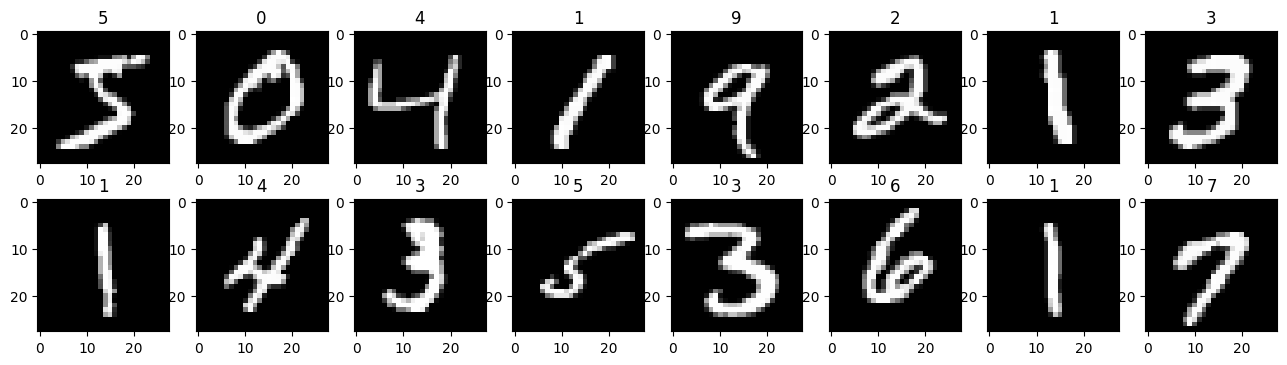

In [3]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for i, ax in enumerate(axes.flat):
  ax.imshow(X_train[i], cmap='gray')
  ax.set_title(y_train[i])

In [4]:
# Chuẩn hóa đầu vào [0, 255] -> [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Bổ sung thông tin về chiều (input => (batch, h, ww, channels))
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

print(f'Data: {X_train.shape}, {X_test.shape}')

Data: (60000, 28, 28, 1), (10000, 28, 28, 1)


In [5]:
# Chuẩn hóa đầu ra = OneHotEncocer, mục đích là số => vector xác suất, ví dụ: 2 => [0, 0, 1, 0, 0, 0, 0, 0, 0]
num_classes = 10
y_train_en = keras.utils.to_categorical(y_train, num_classes)
y_test_en = keras.utils.to_categorical(y_test, num_classes)

print(y_train_en.shape, y_test_en.shape)

(60000, 10) (10000, 10)


In [6]:
print(y_train[0], y_train_en[0])

5 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [7]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential

model = Sequential(
    [
        Conv2D(
            filters=32,
            kernel_size=(3, 3),
            activation='relu',
            input_shape=(28, 28, 1),
            padding='same'
        ),
        # => output (28, 28, 32)
        MaxPooling2D(
            pool_size=(2, 2),
        ),
        # => output (14, 14, 32)
        Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation='relu',
            padding='same'
        ),
        # => output (14, 14, 64)
        MaxPooling2D(
            pool_size=(2, 2),
        ),
        # => output (7, 7, 64)
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
        # => output (10, )
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [10]:
history_log = model.fit(X_train, y_train_en, batch_size=128, epochs=10, validation_split=0.1, verbose=1)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 64s 146ms/step - accuracy: 0.9081 - loss: 0.2948 - val_accuracy: 0.9828 - val_loss: 0.0550
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 64s 152ms/step - accuracy: 0.9727 - loss: 0.0904 - val_accuracy: 0.9883 - val_loss: 0.0457
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 62s 148ms/step - accuracy: 0.9808 - loss: 0.0641 - val_accuracy: 0.9880 - val_loss: 0.0377
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 148ms/step - accuracy: 0.9836 - loss: 0.0545 - val_accuracy: 0.9908 - val_loss: 0.0361
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 62s 147ms/step - accuracy: 0.9870 - loss: 0.0438 - val_accuracy: 0.9907 - val_loss: 0.0369
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 145ms/step - accuracy: 0.9880 - loss: 0.0400 - val_accuracy: 0.9907 - val_loss: 0.0377
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 60s 142ms/step - accuracy: 0.9884 - loss: 0.0361 - val_accuracy: 0.9920 - val_loss: 0.0319
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 144ms/step - accuracy: 0.9904 - loss: 0

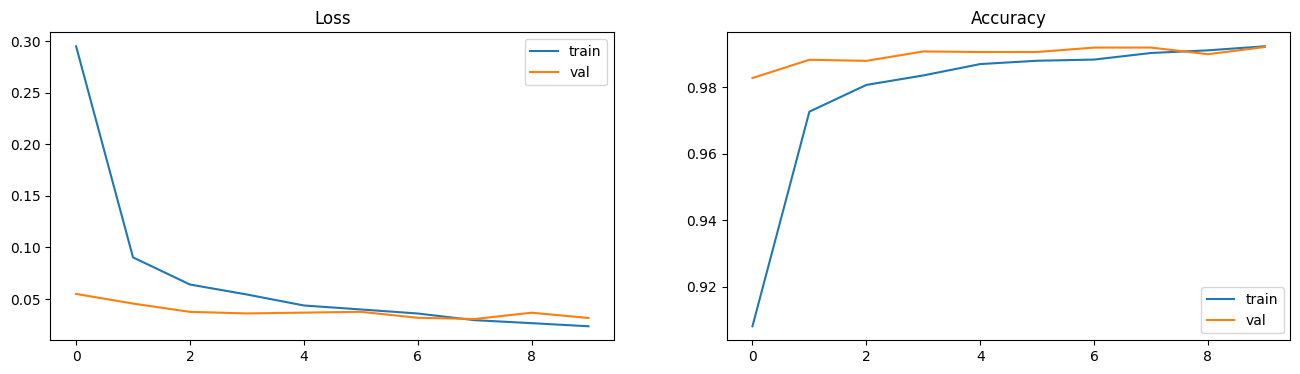

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(history_log.history['loss'], label='train')
axes[0].plot(history_log.history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history_log.history['accuracy'], label='train')
axes[1].plot(history_log.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy')
axes[1].legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


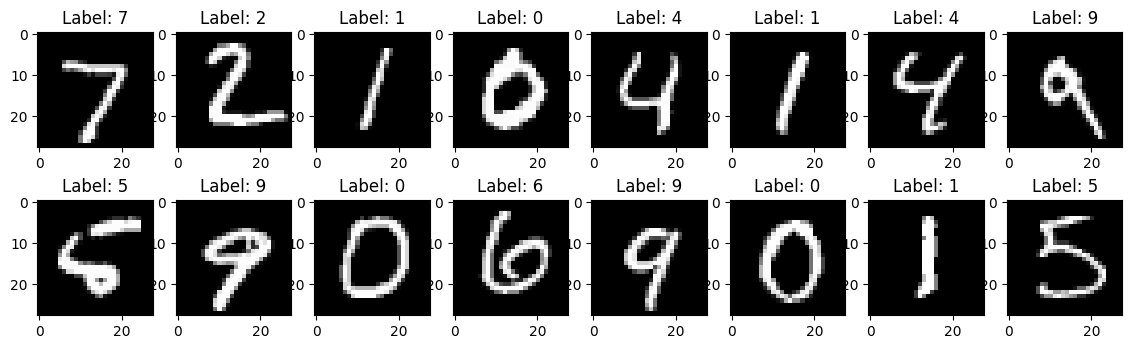

In [13]:
y_pred = model.predict(X_test)      # [0.05, 0.03, 0.72, 0.2, 0, ...]
y_pred = np.argmax(y_pred, axis=1)  # => 2


fig, axes = plt.subplots(2, 8, figsize=(14, 4))

for i, ax in enumerate(axes.flat):
  ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
  ax.set_title(f'Label: {y_pred[i]}')

plt.show()

Số lượng sai: 79


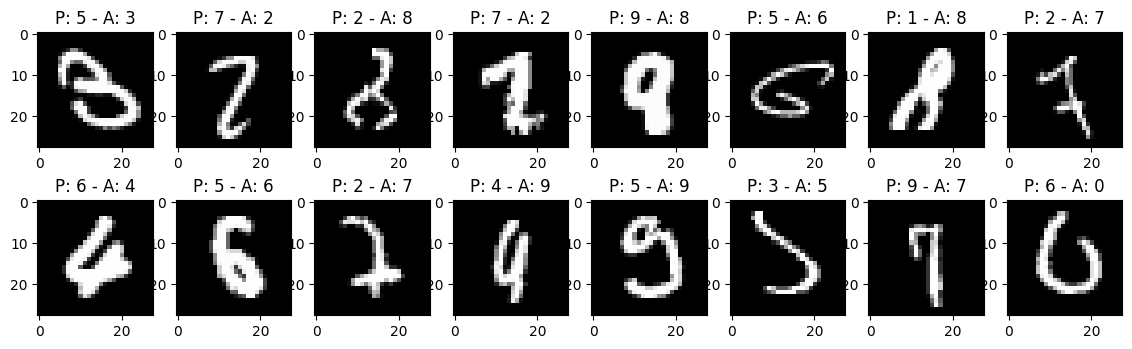

In [15]:
incorrect_guess = np.where(y_pred != y_test)[0]
print(f'Số lượng sai: {len(incorrect_guess)}')

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
  ax.imshow(X_test[incorrect_guess[i]].reshape(28, 28), cmap='gray')
  ax.set_title(f'P: {y_pred[incorrect_guess[i]]} - A: {y_test[incorrect_guess[i]]}')


plt.show()

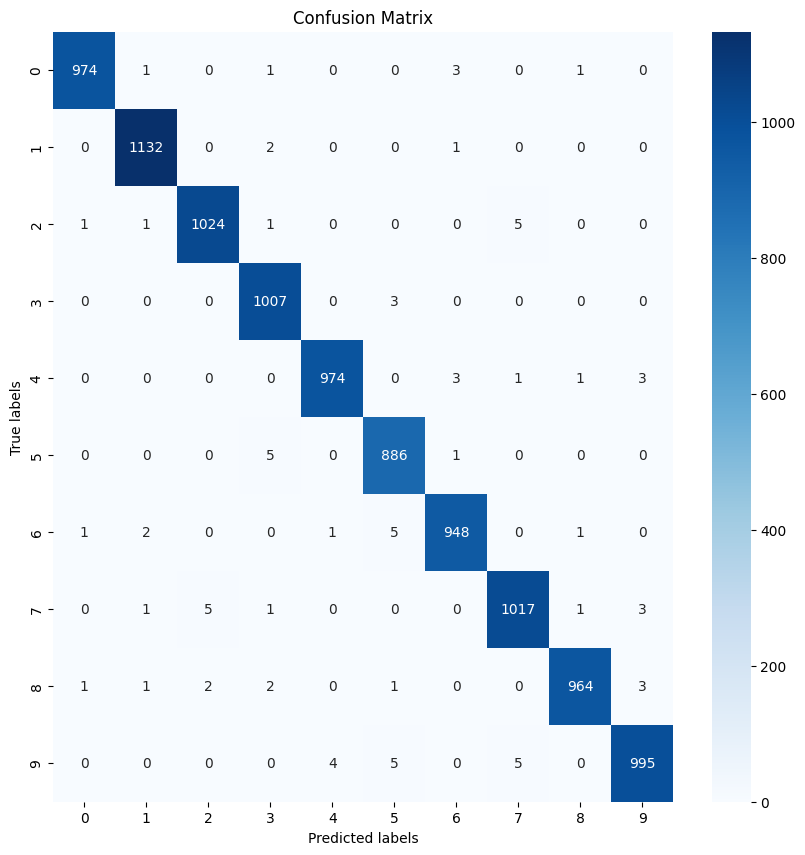

In [16]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
plt.show()

In [17]:
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc}')

Accuracy: 0.9921
